2026-04-07 15:47:08.614453: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775576828.812001      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775576828.862640      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775576829.281428      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775576829.281492      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775576829.281500      24 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1775576856.259739      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775576856.265635      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1775576857.707612      70 service.cc:152] XLA service 0x7c8684002a80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775576857.707645      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775576857.707648      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775576857.803294      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 975ms/step


I0000 00:00:1775576858.571384      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


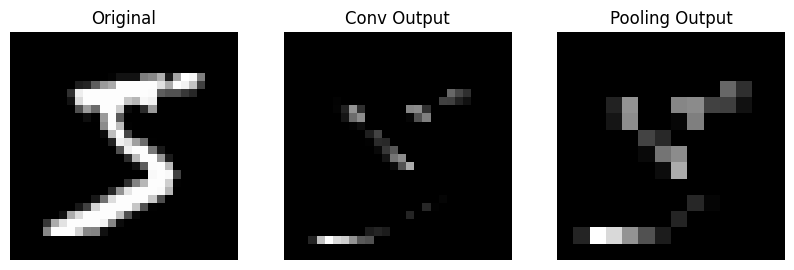

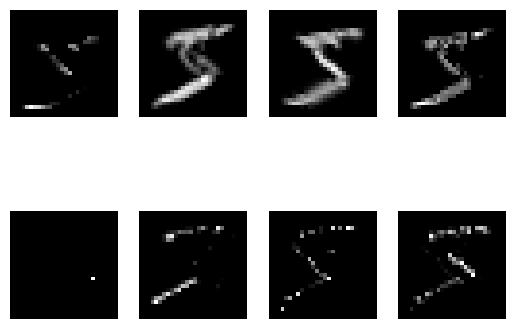

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load dataset
(X_train, y_train), _ = mnist.load_data()

# Take one image
img = X_train[0]
img = img.reshape(1, 28, 28, 1) / 255.0

# Build simple CNN
input_layer = Input(shape=(28,28,1))

conv = Conv2D(8, (3,3), activation='relu', padding='same')(input_layer)
pool = MaxPooling2D((2,2))(conv)

# Create model
model = Model(inputs=input_layer, outputs=[conv, pool])

# Get outputs
conv_output, pool_output = model.predict(img)

# Plot original image
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img[0].reshape(28,28), cmap='gray')
plt.axis('off')

# Plot convolution feature maps
plt.subplot(1,3,2)
plt.title("Conv Output")
plt.imshow(conv_output[0][:,:,0], cmap='gray')
plt.axis('off')

# Plot pooling feature maps
plt.subplot(1,3,3)
plt.title("Pooling Output")
plt.imshow(pool_output[0][:,:,0], cmap='gray')
plt.axis('off')

plt.show()

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(conv_output[0][:,:,i], cmap='gray')
    plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step


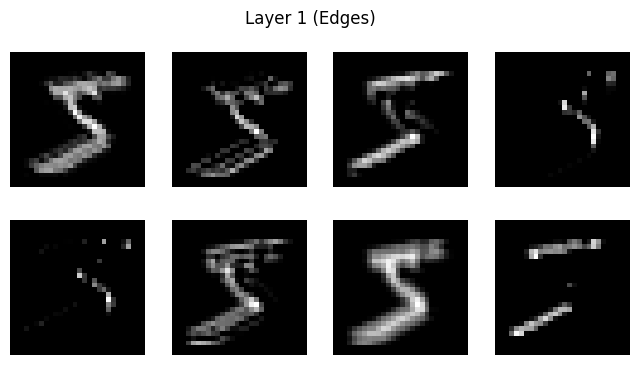

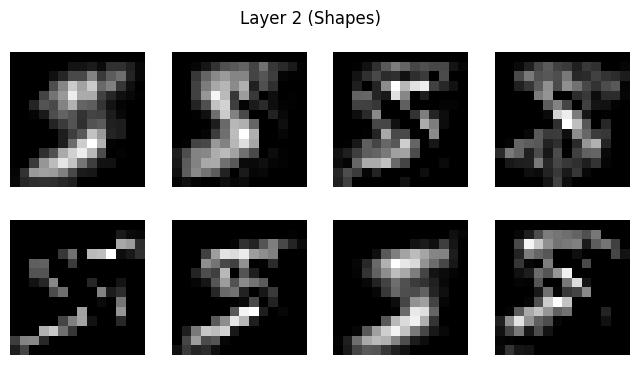

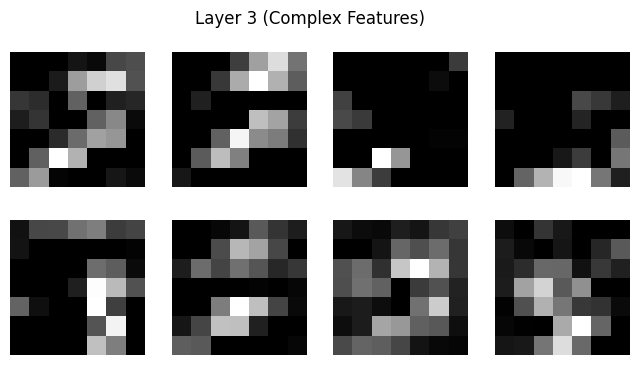

In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load data
(X_train, _), _ = mnist.load_data()

# Take one image
img = X_train[0].reshape(1, 28, 28, 1) / 255.0

# Build CNN
input_layer = Input(shape=(28,28,1))

# Layer 1
x1 = Conv2D(8, (3,3), activation='relu', padding='same')(input_layer)
p1 = MaxPooling2D((2,2))(x1)

# Layer 2
x2 = Conv2D(16, (3,3), activation='relu', padding='same')(p1)
p2 = MaxPooling2D((2,2))(x2)

# Layer 3
x3 = Conv2D(32, (3,3), activation='relu', padding='same')(p2)
p3 = MaxPooling2D((2,2))(x3)

# Model to get outputs
model = Model(inputs=input_layer, outputs=[x1, x2, x3])

# Predict
layer1_output, layer2_output, layer3_output = model.predict(img)

# Function to plot feature maps
def plot_feature_maps(feature_maps, title, num_maps=8):
    plt.figure(figsize=(8,4))
    for i in range(num_maps):
        plt.subplot(2,4,i+1)
        plt.imshow(feature_maps[0][:,:,i], cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Plot layers
plot_feature_maps(layer1_output, "Layer 1 (Edges)")
plot_feature_maps(layer2_output, "Layer 2 (Shapes)")
plot_feature_maps(layer3_output, "Layer 3 (Complex Features)")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8851 - loss: 0.4103
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9741 - loss: 0.0874


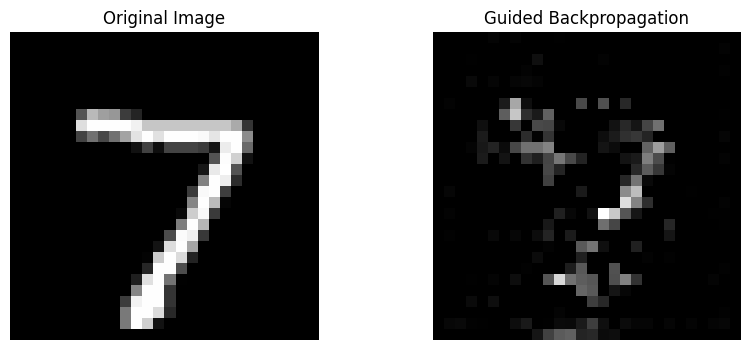

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess
X_train = X_train.reshape(-1,28,28,1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0

# Build model
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train,y_train,epochs=2)

# Take one image
img = X_test[0]
img = img.reshape(1,28,28,1)

# Gradient calculation
img_tensor = tf.convert_to_tensor(img)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    preds = model(img_tensor)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

# Compute gradients
grads = tape.gradient(loss, img_tensor)

# Guided Backprop (keep positive gradients)
guided_grads = tf.maximum(grads, 0)

# Convert to numpy
guided_grads = guided_grads.numpy()[0]

# Plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img[0].reshape(28,28), cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Guided Backpropagation")
plt.imshow(guided_grads[:,:,0], cmap='gray')
plt.axis('off')

plt.show()

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.3450
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1554
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1340
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1243
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1167
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step


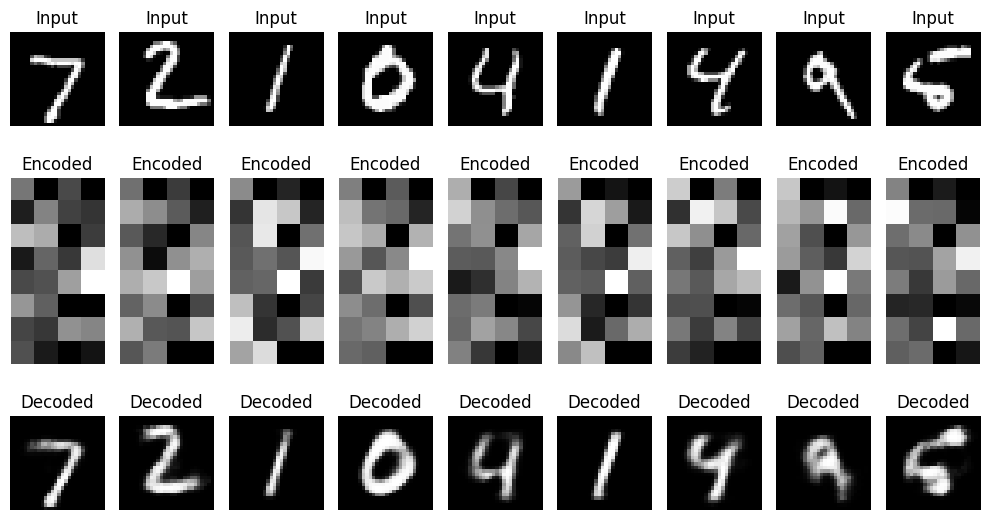

In [4]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Load data
(X_train, _), (X_test, _) = mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten input
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Encoder
input_img = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)  # latent space

# Decoder
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Separate encoder model
encoder = Model(input_img, encoded)

# Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train
autoencoder.fit(X_train, X_train, epochs=5, batch_size=256, shuffle=True)

# Get encoded and decoded images
encoded_imgs = encoder.predict(X_test[:9])
decoded_imgs = autoencoder.predict(X_test[:9])

# Plot
plt.figure(figsize=(10,6))

# Original Images
for i in range(9):
    plt.subplot(3,9,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title("Input")
    plt.axis('off')

# Encoded Images (reshape for visualization)
for i in range(9):
    plt.subplot(3,9,9+i+1)
    plt.imshow(encoded_imgs[i].reshape(8,4), cmap='gray')  # 32 → 8x4
    plt.title("Encoded")
    plt.axis('off')

# Decoded Images
for i in range(9):
    plt.subplot(3,9,18+i+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Decoded")
    plt.axis('off')

plt.tight_layout()
plt.show()